In [17]:
import torch
from dinosaw.wrappers import ModelTypes, MODEL_NAMES, get_models
from dinosaw.utils import do_2D_pca, get_features

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False
torch.cuda.empty_cache()

In [18]:
# enabled_models: tuple[ModelTypes, ...] = ('dinov2_s', 'dvt_dinov2_s', 'alibi_dinov2_s', 'alibi_dinov2_s_no_norm_wrap', 'alibi_dinov2_s_no_norm_no_wrap', 'alibi_dinov3_s+')
# enabled_models: tuple[ModelTypes, ...] = ('dinov3_s+', 'alibi_dinov3_s+', 'alibi_dinov3_s+_norm_wrap_ms', 'alibi_dinov3_s+_no_norm_wrap_ms')
enabled_models: tuple[ModelTypes, ...] = ('dinov2_s', 'dvt_dinov2_s', 'alibi_dinov2_s', 'sinusoid_dinov2_s_cb')
models = get_models(enabled_models, DEVICE, True, "../../models/checkpoints", "../../models/dinov3")

2026-07-23 08:51:47 | I | factory.py                 : 152 | Building wrapper 'dinov2_s' on device cuda:0
2026-07-23 08:51:47 | I | factory.py                 : 131 | Building backbone with config: BackboneConfig(backbone_type='timm', model_arch='dinov2_s', pretrained=True, checkpoint_path=None, model_conf_path='../../models/dinov3', stride=None, remove_pos_embed=False, add_flash_attn=False, dynamic_img_size=True, dynamic_img_pad=False, modifications=[], dtype=torch.float32)
2026-07-23 08:51:47 | I | wrapper.py                 :  48 | Initialized PretrainedViTWrapper - name: '', arch: 'None', device: cuda:0, stride: (14, 14), patch_size: (14, 14), embed_dim: 384, num_blocks: 12
2026-07-23 08:51:47 | I | factory.py                 : 152 | Building wrapper 'dvt_dinov2_s' on device cuda:0
2026-07-23 08:51:47 | I | factory.py                 : 131 | Building backbone with config: BackboneConfig(backbone_type='timm', model_arch='dinov2_s', pretrained=True, checkpoint_path=None, model_conf_p

In [19]:
(518 - 14) 


504

In [41]:
SF = 0.4

img_fname = "tests/black_square_518.png"

_img = Image.open(f"../../images/{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.BILINEAR)

# import numpy as np
# L = 504
# img_arr = np.zeros((L, L, 3), dtype=np.uint8)
# w = models["alibi_dinov2_s"].stride[0]

# for i in range(0, L, 2 * w):
#     img_arr[i:i + w, :, :] = 255

# plt.imshow(img_arr)

# _img = Image.fromarray(img_arr)

In [42]:
features = {}
features_reduced = {}

In [43]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, False)
    features[model_key] = feats

2026-07-23 08:53:11 | I | wrapper.py                 :  92 | Processing image, size: [207, 207]
2026-07-23 08:53:11 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,196,196] -> f: [1,384,14,14]
2026-07-23 08:53:11 | I | wrapper.py                 :  92 | Processing image, size: [207, 207]
2026-07-23 08:53:11 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,196,196] -> f: [1,384,14,14]
2026-07-23 08:53:11 | I | wrapper.py                 :  92 | Processing image, size: [207, 207]
2026-07-23 08:53:11 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,196,196] -> f: [1,384,14,14]
2026-07-23 08:53:11 | I | wrapper.py                 :  92 | Processing image, size: [207, 207]
2026-07-23 08:53:11 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,196,196] -> f: [1,384,14,14]


In [44]:
for model_key in enabled_models:
    feats = features[model_key]
    features_reduced[model_key] = do_2D_pca(feats, 9, pre_norm=None, post_norm='minmax')

/tmp/ipykernel_759679/342820180.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


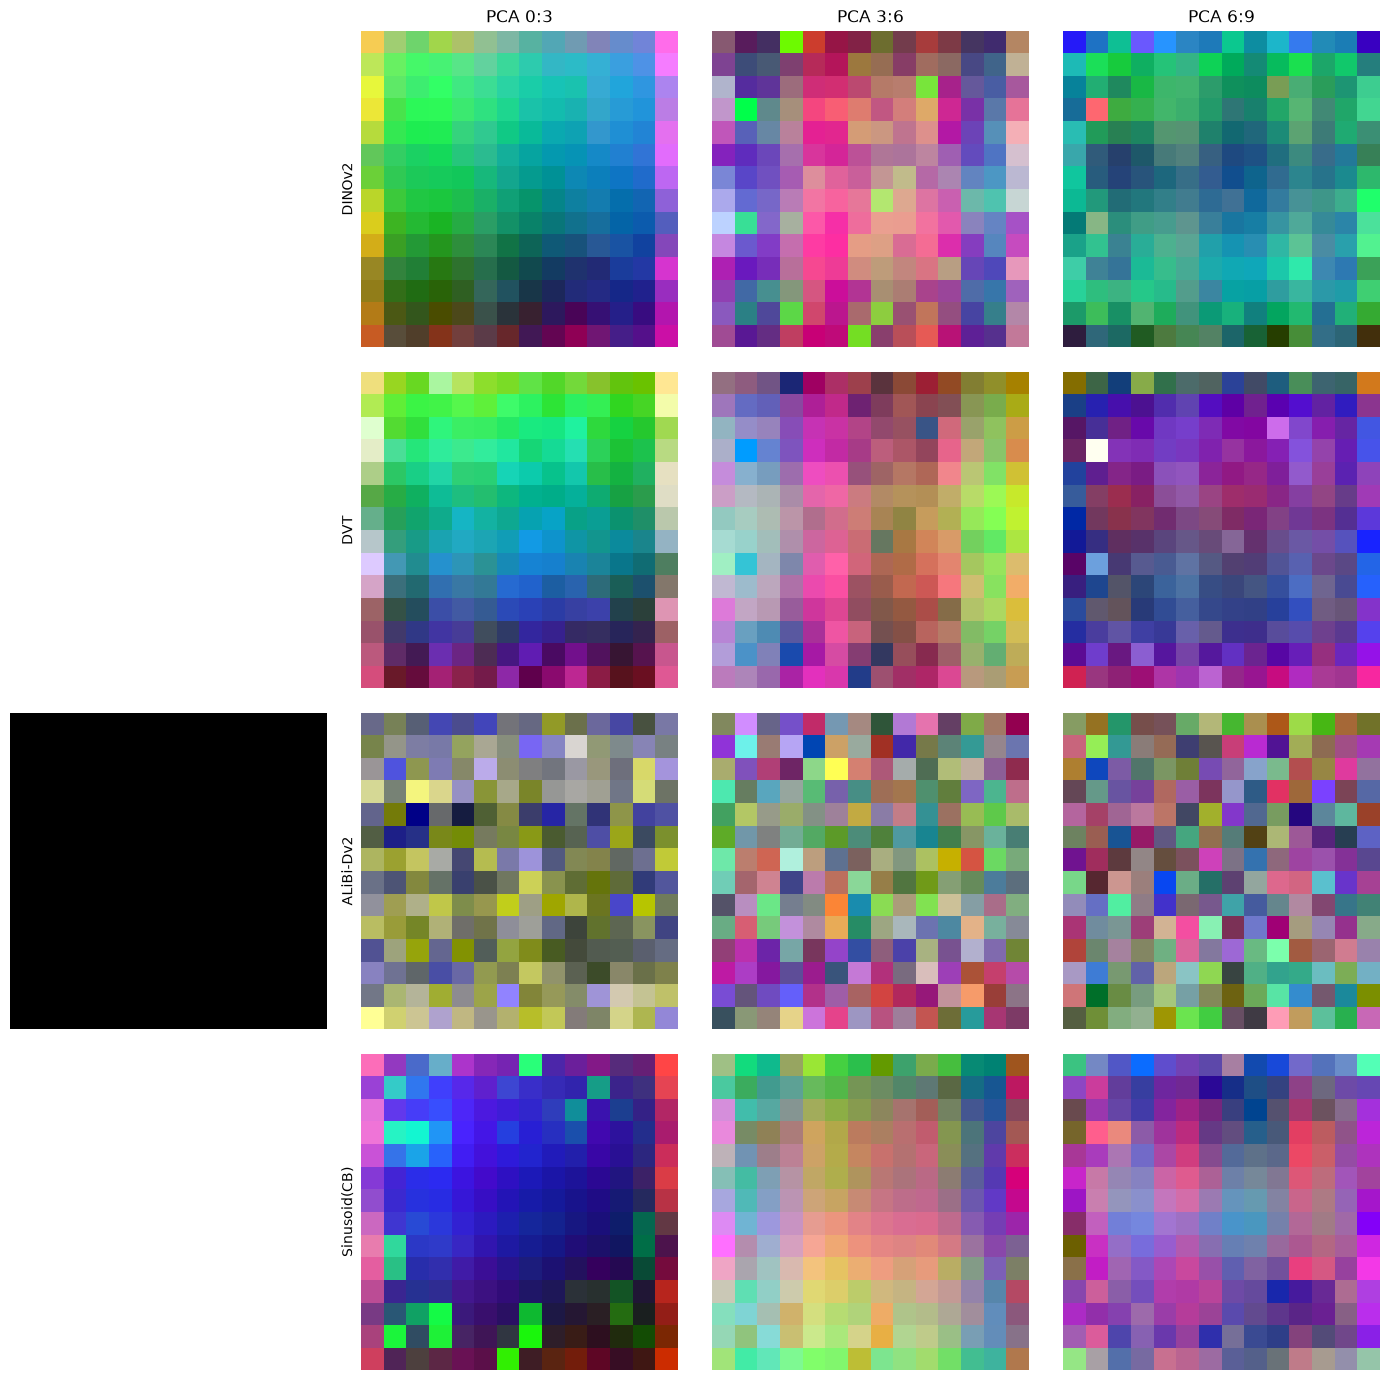

In [45]:
# %%capture
def hide_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

sf = _img.width / _img.height
L = 3.5
w, h = L * sf, L
nrows, ncols = len(enabled_models), 4
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(w * ncols, h * nrows), constrained_layout=True)


img_ax = axs[nrows // 2, 0]
img_ax.imshow(_img)
img_ax.set_axis_off()
for ax in axs.flatten():
    hide_axes(ax)


for i, model_key in enumerate(enabled_models):
    for pca_idx in (0, 1, 2):
        feats_red = features_reduced[model_key]
        idx_0, idx_1 = pca_idx * 3, (pca_idx + 1) * 3
        components = feats_red[:, :, (pca_idx * 3):((pca_idx + 1) * 3)]

        ax = axs[i, 1 + pca_idx  ]
        ax.imshow(components)
        if pca_idx == 0:
            ax.set_ylabel(MODEL_NAMES[model_key])

        if i == 0:
            ax.set_title(f"PCA {idx_0}:{idx_1}", fontsize=12)
plt.tight_layout()